# Task 8: Language Detection
### Predict the language of short sentences (English, French, Urdu, Spanish)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings("ignore")


In [2]:
sentences = [
    ("Hello, how are you today?", "English"),
    ("The weather is very nice.", "English"),
    ("I love learning new languages.", "English"),
    ("She went to the market.", "English"),
    ("The book is on the table.", "English"),
    ("He works at a software company.", "English"),
    ("My name is Ahmed.", "English"),
    ("Bonjour, comment allez-vous?", "French"),
    ("Je suis très content aujourd hui.", "French"),
    ("La vie est belle et magnifique.", "French"),
    ("Nous allons au marché demain.", "French"),
    ("Il fait beau temps aujourd hui.", "French"),
    ("J aime beaucoup la musique classique.", "French"),
    ("Merci pour votre aide précieuse.", "French"),
    ("Hola, como estas hoy?", "Spanish"),
    ("Me gusta mucho este libro.", "Spanish"),
    ("El tiempo esta muy agradable.", "Spanish"),
    ("Vamos al mercado manana.", "Spanish"),
    ("Ella trabaja en una empresa.", "Spanish"),
    ("Buenos dias, como te llamas?", "Spanish"),
    ("Me llamo Carlos y soy de Madrid.", "Spanish"),
    ("آپ کیسے ہیں آج؟", "Urdu"),
    ("میں ٹھیک ہوں شکریہ۔", "Urdu"),
    ("پاکستان ایک خوبصورت ملک ہے۔", "Urdu"),
    ("آج موسم بہت اچھا ہے۔", "Urdu"),
    ("وہ بازار گئی ہے۔", "Urdu"),
    ("کتاب میز پر رکھی ہے۔", "Urdu"),
    ("مجھے اردو پڑھنا پسند ہے۔", "Urdu"),
    ("The sky is clear and blue.", "English"),
    ("Il aime jouer au football.", "French"),
]
df = pd.DataFrame(sentences, columns=["sentence","language"])
print(df)
print("\nLanguage Distribution:")
print(df["language"].value_counts())


                                 sentence language
0               Hello, how are you today?  English
1               The weather is very nice.  English
2          I love learning new languages.  English
3                 She went to the market.  English
4               The book is on the table.  English
5         He works at a software company.  English
6                       My name is Ahmed.  English
7            Bonjour, comment allez-vous?   French
8       Je suis très content aujourd hui.   French
9         La vie est belle et magnifique.   French
10          Nous allons au marché demain.   French
11        Il fait beau temps aujourd hui.   French
12  J aime beaucoup la musique classique.   French
13       Merci pour votre aide précieuse.   French
14                  Hola, como estas hoy?  Spanish
15             Me gusta mucho este libro.  Spanish
16          El tiempo esta muy agradable.  Spanish
17               Vamos al mercado manana.  Spanish
18           Ella trabaja en un

In [ ]:
tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(2,3))
X = tfidf.fit_transform(df["sentence"])
y = df["language"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


✅ Accuracy: 100.0 %

📊 Classification Report:
              precision    recall  f1-score   support

     English       1.00      1.00      1.00         2
      French       1.00      1.00      1.00         2
     Spanish       1.00      1.00      1.00         2
        Urdu       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



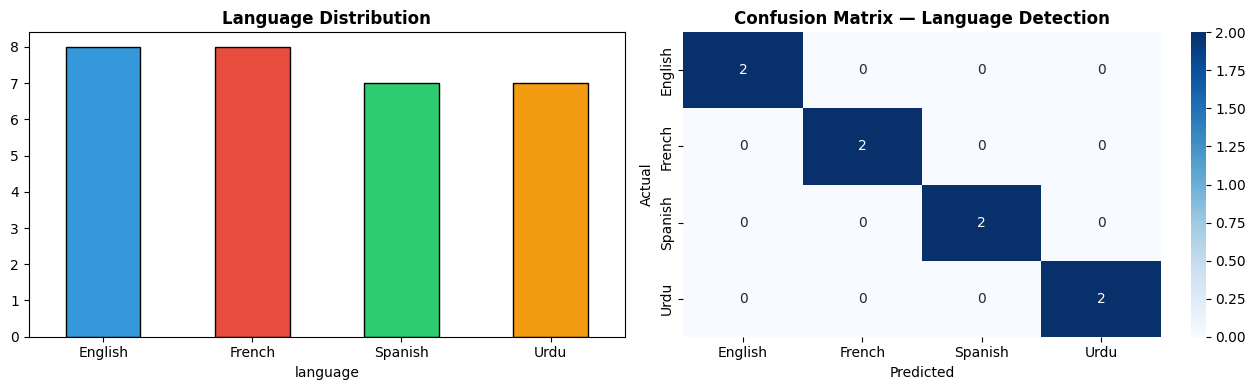

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["language"].value_counts().plot(kind="bar", ax=axes[0], color=["#3498db","#e74c3c","#2ecc71","#f39c12"],
    edgecolor="black")
axes[0].set_title("Language Distribution", fontweight="bold"); axes[0].tick_params(rotation=0)

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=model.classes_, yticklabels=model.classes_)
axes[1].set_title("Confusion Matrix — Language Detection", fontweight="bold")
axes[1].set_ylabel("Actual"); axes[1].set_xlabel("Predicted")
plt.tight_layout(); plt.savefig("task8_viz.png", dpi=100); plt.show()


In [ ]:
# Test on new sentences
test_sents = ["I enjoy watching cricket.", "Je parle francais couramment.", "Mujhe khana chahiye.", "Me gusta aprender."]
X_new = tfidf.transform(test_sents)
preds = model.predict(X_new)
for s, p in zip(test_sents, preds):
    print(f"'{s}'  →   {p}")


'I enjoy watching cricket.'  →  🌐 English
'Je parle francais couramment.'  →  🌐 French
'Mujhe khana chahiye.'  →  🌐 English
'Me gusta aprender.'  →  🌐 Spanish
